# Dynamical clustering 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

_______
# Data

In [2]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[1])


nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [3]:
dfs = DSD.to_dataframe().reset_index().set_index('row_number')
dfs = dfs[(dfs.sume<1e-4) & (dfs.sumn<1e-4)]

<Axes: ylabel='Frequency'>

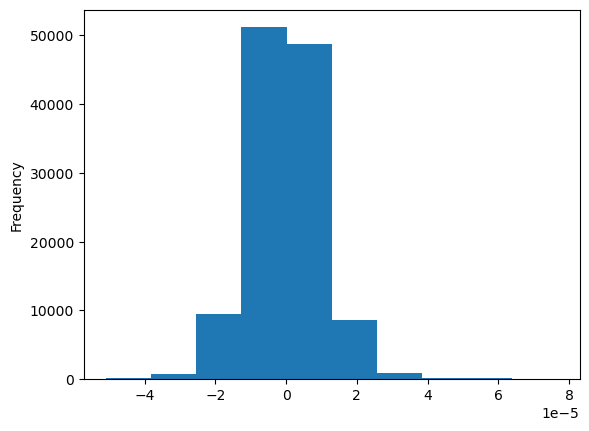

In [4]:
dfs.sume.plot.hist()

In [6]:
Xn = [k for k in ds.keys() if 'Xn' in k]
Xe = [k for k in ds.keys() if 'Xe' in k]
dl=0.05
lonbins = np.arange(0.9, 6.1, dl)
latbins = np.arange(37.9, 43.4, dl)
df = dfs.copy()
df['longitude_cut']= pd.cut(df['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
df['latitude_cut']= pd.cut(df['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)
ds = compute_mean_square_groupby(df, groupby = [ 'latitude_cut','longitude_cut'])
for xn in Xn :
    ds[xn.replace('Xn_', 'X_')] = ds[xn]+ds[xn.replace('Xn_', 'Xe_')]

In [152]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:        (latitude_cut: 109, longitude_cut: 103)
Coordinates:
  * latitude_cut   (latitude_cut) float64 872B 37.92 37.97 38.02 ... 43.27 43.32
  * longitude_cut  (longitude_cut) float64 824B 0.925 0.975 ... 5.975 6.025
Data variables: (12/47)
    ACCn           (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    CORn           (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    GGDn           (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    WDn            (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    Sn             (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    ACCe           (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    ...             ...
    X_acc_cor      (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    X_acc_ggd      (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    X_acc_wd       (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    X_cor_ggd      (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    X_cor_wd       (latitude_cut, longitude_cut) float64 90kB nan nan ... nan
    X_ggd_wd       (latitude_cut, longitude_cut) float64 90kB nan nan ... nan

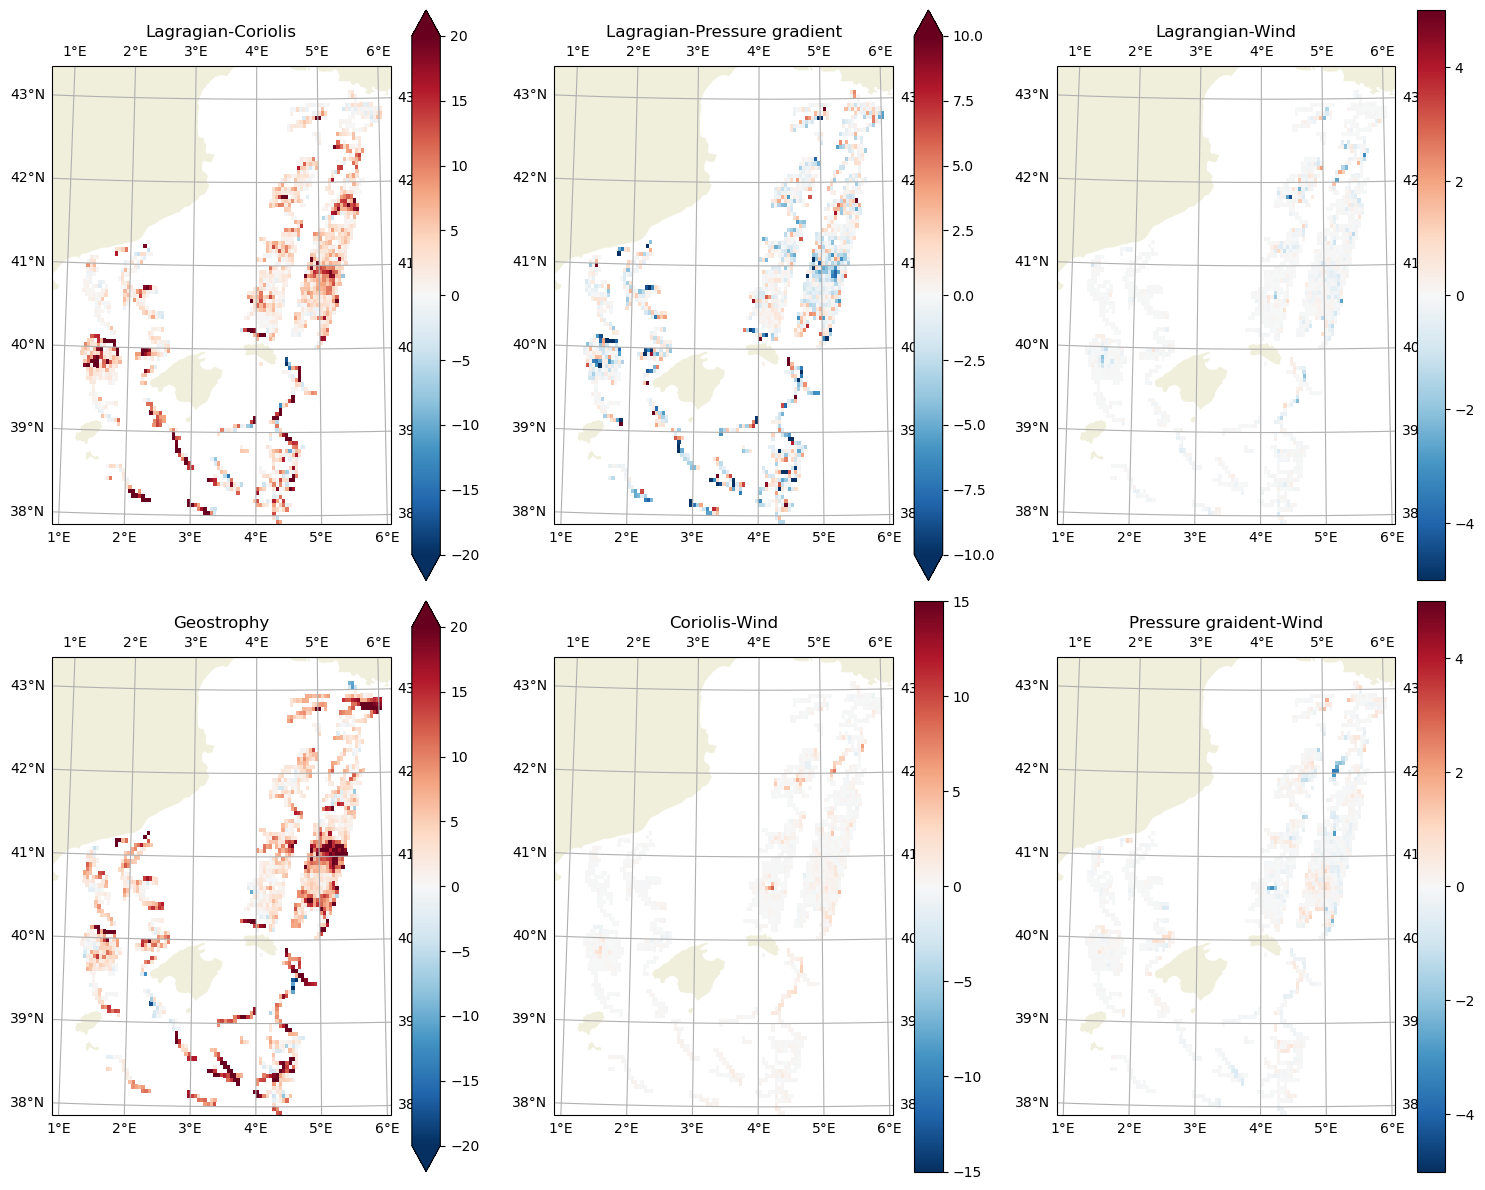

In [7]:
fig = plt.figure(figsize=(15,12))
#plot pair's contributions
Xn = [k for k in ds.keys() if 'Xn' in k]
Xe = [k for k in ds.keys() if 'Xe' in k]
title=['Lagragian-Coriolis', 'Lagragian-Pressure gradient', 'Lagrangian-Wind', 'Geostrophy', 'Coriolis-Wind', 'Pressure graident-Wind']
v = [20, 10, 5, 20, 15, 5]
for i in range(len(Xn)):
    ax = fig.add_subplot(2, 3, i+1, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    xn, xe = Xn[i], Xe[i]
    (ds[xn]+ds[xe]).plot(ax=ax, label=xn, transform=crs, vmin = -v[i], vmax=v[i], cmap = 'RdBu_r')#, **xstyle[xn.replace('Xn_', '')])
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    ax.set_title(title[i])
    #ds[xe].plot(ax=ax, label=xe)#, **xstyle[xe.replace('Xe_', '')])
    
fig.tight_layout()

____________
# Spectral decomp 


In [9]:
dtypes = {'drifter_id':str}
def prepared_drifters(drifter_key) : 
    dfr = pd.read_csv(DRIFTER[drifter_key], parse_dates=['datetime'], dtype=dtypes).set_index('row_number')
    dfr['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr['core']= -dfr.f * dfr.velocity_north
    dfr['corn']= dfr.f * dfr.velocity_east
    dfr = dfr.rename(columns = {'acceleration_north':'accn', 'acceleration_east':'acce'})
    return dfr

dfr = prepared_drifters('nofilter') 
dfr['inertial_U'] = np.sqrt(dfr.inertial_velocity_east**2 + dfr.inertial_velocity_north**2)
dfr['inertial_A'] = np.sqrt(dfr.inertial_acceleration_east**2 + dfr.inertial_acceleration_north**2)
dfr['other_U'] = np.sqrt(dfr.other_velocity_east**2 + dfr.other_velocity_north**2)
dfr['diurnal_U'] = np.sqrt(dfr.diurnal_velocity_east**2 + dfr.diurnal_velocity_north**2)
dfr['semidiurnal_U'] = np.sqrt(dfr.semidiurnal_velocity_east**2 + dfr.semidiurnal_velocity_north**2)

dl=0.05
lonbins = np.arange(0.9, 6.1, dl)
latbins = np.arange(37.9, 43.4, dl)

dfu = pd.concat([dfs, dfr[['inertial_U', 'other_U', 'diurnal_U', 'semidiurnal_U', 'f']]], axis=1).dropna().reset_index()
dfu['longitude_cut']= pd.cut(dfu['longitude'], lonbins, labels=(lonbins[1:] + lonbins[:-1])/2)
dfu['latitude_cut']= pd.cut(dfu['latitude'], latbins, labels=(latbins[1:] + latbins[:-1])/2)

dsu = dfu[['longitude_cut', 'latitude_cut','inertial_U', 'other_U', 'diurnal_U', 'semidiurnal_U', 'f']].groupby([ 'latitude_cut','longitude_cut'], observed=False).mean().to_xarray()


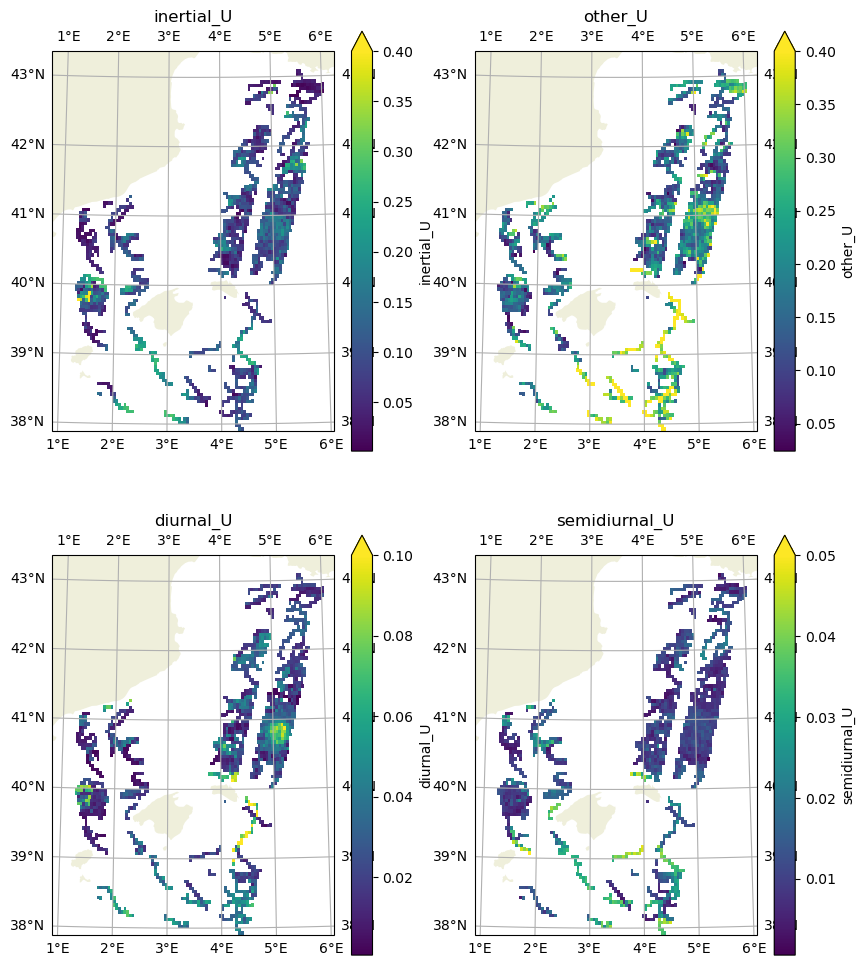

In [18]:
dsu = dfu[['longitude_cut', 'latitude_cut','inertial_U', 'other_U', 'diurnal_U', 'semidiurnal_U', 'f']].groupby([ 'latitude_cut','longitude_cut'], observed=False).mean().to_xarray()
comp = ['inertial_U', 'other_U', 'diurnal_U', 'semidiurnal_U']
vmax = [0.4, 0.4, 0.1, 0.05]
fig = plt.figure(figsize=(10,12))
for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection=ccrs.Orthographic(3.5, 40.5))
    dsu[comp[i]].plot(ax=ax, transform=crs, vmax =vmax[i] )
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    ax.set_title(comp[i])

Text(0.5, 1.0, 'Inertial period')

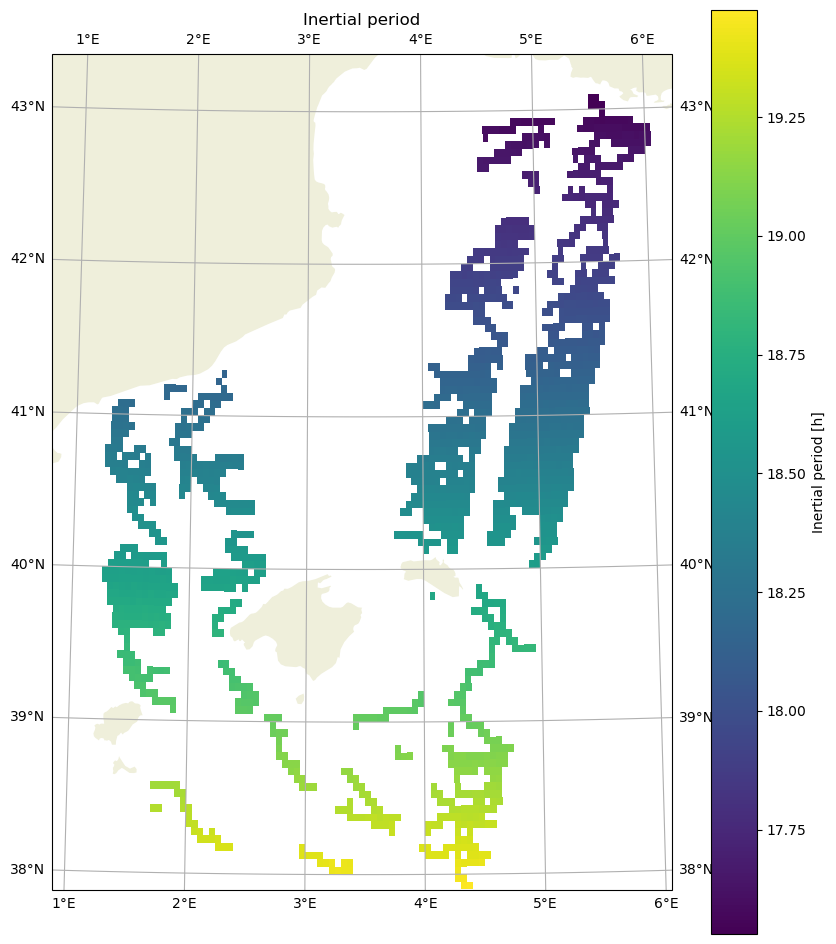

In [11]:
fig = plt.figure(figsize=(10,12))
ax = fig.add_subplot(111, projection=ccrs.Orthographic(3.5, 40.5))
(2*np.pi/dsu['f']/3600).assign_attrs({'long_name':'Inertial period', 'units':'h'}).plot(ax=ax, transform=crs, )
ax.add_feature(cfeature.LAND,)
gl = ax.gridlines(draw_labels=True,)
ax.set_title('Inertial period')